# Proyecto de Visualización — Sesión 3: JointPlot y Altair
**Bootcamp Python PY4 · Módulo 1 · Semana 4**

---


| Sección | Herramienta | Qué vamos a construir |
|---|---|---|
| A | Seaborn JointPlot | Relación entre `lifespan` y `mass` por grupo taxonómico |
| B | Altair — chart 1 | Strip plot + box plot: distribución de observaciones por parque |
| C | Altair — chart 2 | Linked selection: dos gráficos que se filtran mutuamente |




## 1. Setup y carga de datos

Cargamos el dataset limpio de la Sesión 1.
Esta versión incluye dos columnas numéricas nuevas que no estaban
en el dataset original: `lifespan` (años) y `mass` (kg).


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Carga desde el checkpoint de Sesión 1
#df = pd.read_csv("biodiversity_clean.csv")

# Alternativa si no tienes el archivo:
BASE_URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/"
species = pd.read_csv(BASE_URL + "species_info.csv")
observations = pd.read_csv(BASE_URL + "observations.csv")
species["conservation_status"] = species["conservation_status"].fillna("No Concern")
park_names = {
    "Great Smoky Mountains National Park": "Great Smoky Mts.",
    "Yellowstone National Park": "Yellowstone",
    "Yosemite National Park": "Yosemite",
    "Bryce National Park": "Bryce Canyon"
}
observations["park_short"] = observations["park_name"].map(park_names)
df = observations.merge(species, on="scientific_name", how="left")
df["conservation_status"] = df["conservation_status"].fillna("No Concern")
df["category"] = df["category"].fillna("Unknown")
df = df[df["mass_kg"] < 40]
df = df[df["lifespan_years"] < 50]

print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Columnas: {df.columns.tolist()}")


Dataset: 17,366 filas x 9 columnas
Columnas: ['scientific_name', 'park_name', 'observations', 'park_short', 'category', 'common_names', 'conservation_status', 'lifespan_years', 'mass_kg']


In [69]:
# Verificamos las columnas nuevas
print("Estadísticas de lifespan y mass:")
print(df[["lifespan_years", "mass_kg"]].describe().round(2))


Estadísticas de lifespan y mass:
       lifespan_years   mass_kg
count        17366.00  17366.00
mean             8.47      1.96
std              8.79      4.38
min              0.50      0.00
25%              2.70      0.14
50%              5.40      0.49
75%             10.80      1.62
max             49.40     39.59


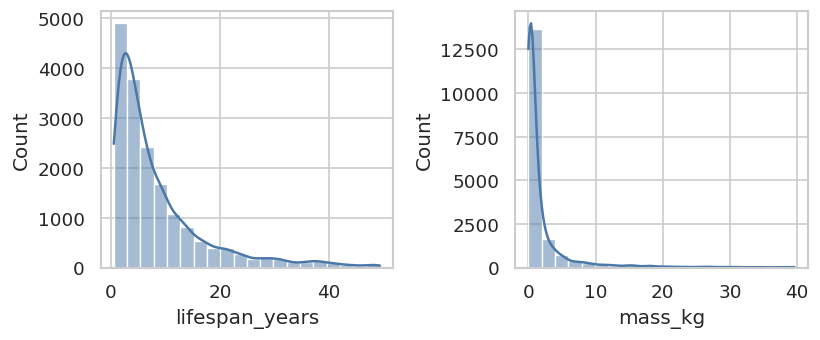

In [70]:
# make two small histogramm of lifespan and mass values newt to each other
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
sns.histplot(
    data=df,
    x="lifespan_years",
    bins=20,
    kde=True,
    color="#4c78a8",
    ax=ax[0]
)
sns.histplot(
    data=df,
    x="mass_kg",
    bins=20,
    kde=True,
    color="#4c78a8",
    ax=ax[1]
)
plt.tight_layout()

In [71]:
# quitamos los datos de vascular plant y non vascular plant
df = df[df["category"] != "Vascular Plant"]
df = df[df["category"] != "Nonvascular Plant"]

print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset: 3,312 filas x 9 columnas


In [72]:
especies_unicas = (
    df.groupby("scientific_name")
    .agg(
        category=("category", "first"),
        conservation_status=("conservation_status", "first"),
        lifespan=("lifespan_years", "mean"),  # Cambiado a 'mean' para obtener el promedio
        mass=("mass_kg", "mean")             # Cambiado a 'mean' para obtener el promedio
    )
    .reset_index()
    .dropna(subset=["lifespan", "mass"])
)

print(f"Especies con lifespan y mass: {len(especies_unicas):,}")
especies_unicas.head(5)


Especies con lifespan y mass: 925


,scientific_name,category,conservation_status,lifespan,mass
0,Acanthus flammea,Bird,Threatened,10.0,0.134
1,Accipiter cooperii,Bird,Species of Concern,7.8,0.567
2,Accipiter gentilis,Bird,Endangered,3.8,0.294
3,Accipiter striatus,Bird,Species of Concern,4.0,0.086
4,Acris crepitans crepitans,Amphibian,No Concern,1.6,0.501


---
## A. JointPlot con Seaborn

### ¿Qué es un JointPlot?

Un JointPlot combina **tres vistas en una sola figura**:
- El gráfico central muestra la relación entre dos variables (scatter, hex, kde...)
- El margen superior muestra la distribución de la variable X
- El margen derecho muestra la distribución de la variable Y

Es útil cuando quieres ver correlación y distribución al mismo tiempo,
sin necesitar dos gráficos separados.

```
         [ distribución de X ]
         ┌───────────────────┐ ─
         │                   │ |
         │   scatter/kde     │ [dist Y]
         │                   │ |
         └───────────────────┘ ─
```

**Pregunta que vamos a responder:**
¿Existe una relación entre la longevidad (`lifespan`) y la masa corporal (`mass`)
de las especies, y varía ese patrón según el grupo taxonómico?


### A.1 JointPlot básico

Empezamos con la versión más simple: scatter en el centro,
histogramas en los márgenes. Sin color por categoría todavía.


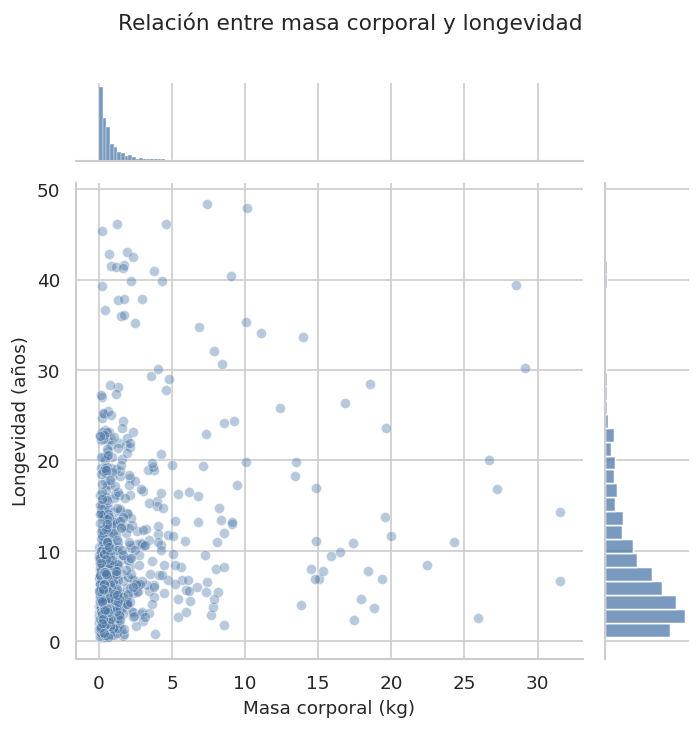

In [73]:
# JointPlot básico: lifespan vs mass
g = sns.jointplot(
    data=especies_unicas,
    x="mass",
    y="lifespan",
    kind="scatter",
    height=6,
    alpha=0.4,
    color="#4c78a8"
)

g.ax_joint.set_xlabel("Masa corporal (kg)", fontsize=11)
g.ax_joint.set_ylabel("Longevidad (años)", fontsize=11)
g.figure.suptitle("Relación entre masa corporal y longevidad", y=1.01, fontsize=13)

plt.tight_layout()
plt.show()


El gráfico es difícil de leer porque `mass` tiene valores extremos
(algunas especies son mucho más grandes que las demás).
Una transformación logarítmica en ambos ejes hace la distribución
mucho más legible — esto es muy común en datos biológicos.


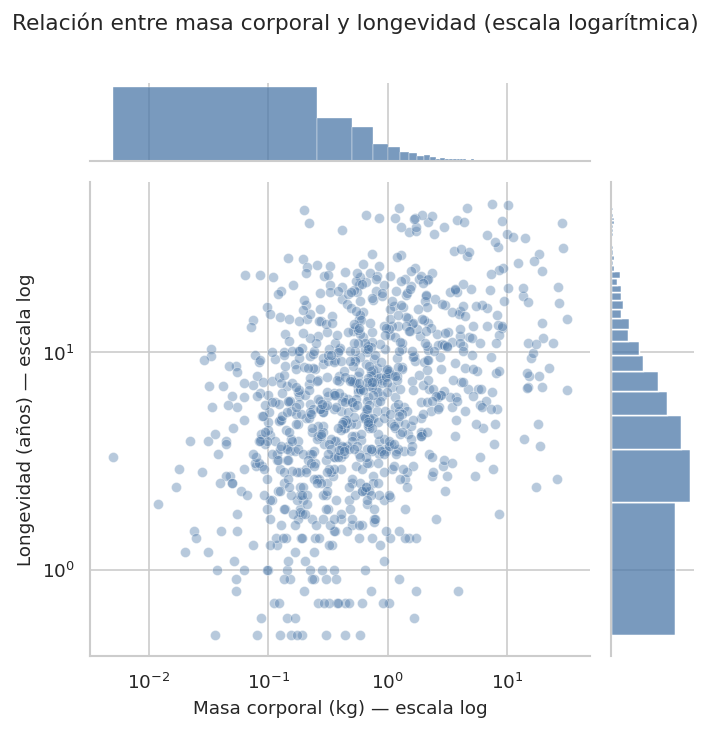

In [74]:
# JointPlot con escala logarítmica
g = sns.jointplot(
    data=especies_unicas,
    x="mass",
    y="lifespan",
    kind="scatter",
    height=6,
    alpha=0.4,
    color="#4c78a8"
)

# Aplicamos escala log en ambos ejes
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")

g.ax_joint.set_xlabel("Masa corporal (kg) — escala log", fontsize=11)
g.ax_joint.set_ylabel("Longevidad (años) — escala log", fontsize=11)
g.figure.suptitle("Relación entre masa corporal y longevidad (escala logarítmica)",
                   y=1.01, fontsize=13)

plt.tight_layout()
plt.show()


### A.2 JointPlot con color por categoría taxonómica

Seaborn no tiene un parámetro `hue` directo en `jointplot`,
pero podemos lograrlo de dos maneras:

**Opción A:** usar `sns.scatterplot()` directamente sobre el `ax_joint`
después de crear el jointplot base.

**Opción B:** usar `sns.JointGrid()` para construirlo manualmente
con control total sobre cada parte.

Vamos con la Opción B — es más código pero enseña cómo funciona
la estructura interna de JointGrid.


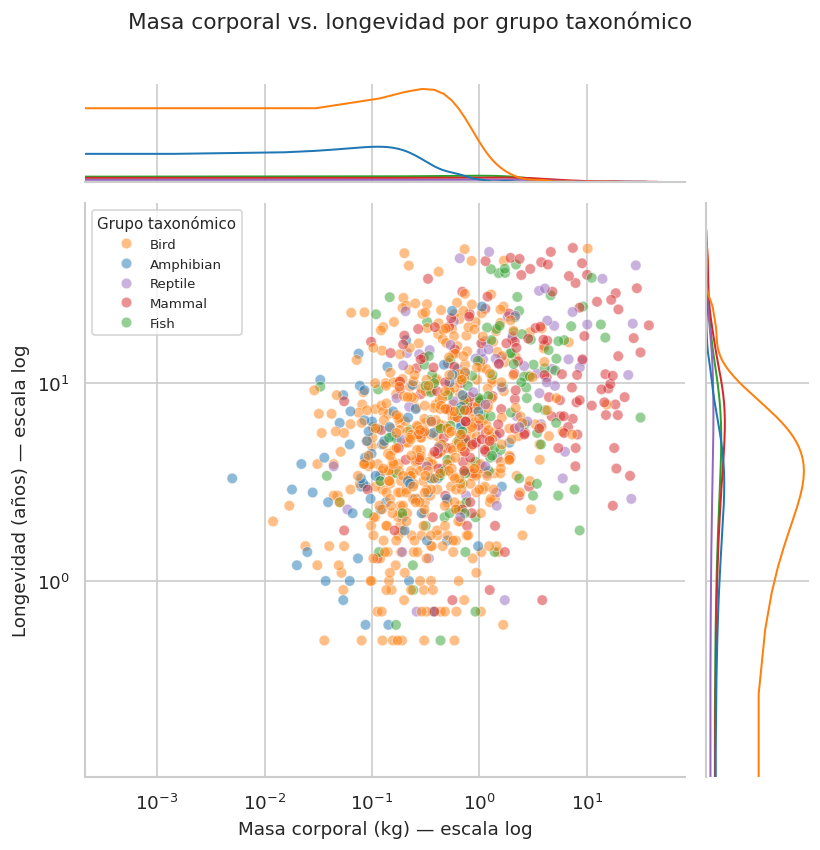

In [ ]:
# Paleta de colores por categoría taxonómica
categorias = especies_unicas["category"].unique()
paleta = dict(zip(
    sorted(categorias),
    sns.color_palette("tab10", n_colors=len(categorias))
))

# Construimos el JointGrid manualmente
g = sns.JointGrid(data=especies_unicas, x="mass", y="lifespan", height=7)

# Gráfico central: scatter con color por categoría
sns.scatterplot(
    data=especies_unicas,
    x="mass",
    y="lifespan",
    hue="category",
    palette=paleta,
    alpha=0.5,
    s=40,
    ax=g.ax_joint,
    legend="brief"
)

# Márgenes: distribución KDE por categoría
sns.kdeplot(
    data=especies_unicas,
    x="mass",
    hue="category",
    palette=paleta,
    ax=g.ax_marg_x,
    legend=False,
    fill=False,
    linewidth=1.2
)

sns.kdeplot(
    data=especies_unicas,
    y="lifespan",
    hue="category",
    palette=paleta,
    ax=g.ax_marg_y,
    legend=False,
    fill=False,
    linewidth=1.2
)

# Escala logarítmica en ambos ejes
g.ax_joint.set_xscale("log")
g.ax_joint.set_yscale("log")

g.ax_joint.set_xlabel("Masa corporal (kg) — escala log", fontsize=11)
g.ax_joint.set_ylabel("Longevidad (años) — escala log", fontsize=11)

# Leyenda dentro del gráfico
g.ax_joint.legend(
    title="Grupo taxonómico",
    fontsize=8,
    title_fontsize=9,
    loc="upper left",
    frameon=True,
    framealpha=0.8
)

g.figure.suptitle(
    "Masa corporal vs. longevidad por grupo taxonómico",
    y=1.01, fontsize=13
)

plt.tight_layout()
plt.savefig("viz_jointplot.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretación — JointPlot

Mira el gráfico central y los márgenes para responder:

- **¿Existe una tendencia general entre masa y longevidad?**
  *(los animales más grandes tienden a vivir más o menos?)*
- **¿Qué grupo taxonómico tiene la mayor masa corporal? ¿Y la mayor longevidad?**
- **¿Los márgenes KDE muestran distribuciones separadas por categoría
  o se solapan mucho?** *(¿son grupos realmente distintos?)*
- **¿Hay outliers notables?** *(especies con masa muy alta pero poca longevidad,
  o viceversa)*
- **Narrativa en una frase:** *[escribe aquí tu hallazgo principal]*


---
## B. Altair — Chart 1: Strip Plot + Box Plot

### ¿Por qué Altair?

Altair usa una **gramática de gráficos declarativa**: describes *qué* quieres mostrar
a través de encodings (x, y, color, size...), no *cómo* dibujarlo paso a paso.
El resultado es código más corto, más legible, y fácil de extender.

La estructura básica de cualquier chart en Altair es:

```python
alt.Chart(datos)
   .mark_TIPO()        # tipo de marca: point, bar, boxplot, line...
   .encode(
       x="columna:T",  # T = temporal, Q = quantitative, N = nominal, O = ordinal
       y="columna:Q",
       color="columna:N"
   )
```

### Viz 05 — Strip Plot + Box Plot
**Pregunta:** ¿En qué parques ocurren las recuperaciones más exitosas?

Filtramos solo las especies *In Recovery* y mostramos la distribución
de observaciones por parque. La combinación de puntos individuales
y resumen estadístico permite ver tanto los valores extremos
como la tendencia central.


In [ ]:
# Filtramos solo las especies In Recovery
df_recovery = df[df["conservation_status"] == "In Recovery"].copy()

print(f"Registros In Recovery: {len(df_recovery):,}")
print(f"Parques presentes: {df_recovery['park_short'].unique()}")
print(f"\nObservaciones por parque:")
print(df_recovery.groupby("park_short")["observations"].describe().round(1))


Registros In Recovery: 173
Parques presentes: ['Great Smoky Mts.' 'Yellowstone' 'Bryce Canyon' 'Yosemite']

Observaciones por parque:
                  count   mean   std    min    25%    50%    75%    max
park_short                                                             
Bryce Canyon       24.0   92.3  27.7   29.0   72.8   89.5  111.0  155.0
Great Smoky Mts.   53.0   72.4  23.3   14.0   59.0   72.0   91.0  117.0
Yellowstone        42.0  252.1  58.9  159.0  228.2  248.0  264.8  538.0
Yosemite           54.0  137.5  27.7   35.0  123.5  140.5  157.0  190.0


Construimos el gráfico en dos capas y las superponemos con el operador `+`:
- **Capa 1:** `mark_boxplot()` — resumen estadístico (mediana, IQR, outliers)
- **Capa 2:** `mark_point()` — puntos individuales con jitter para ver la densidad


In [ ]:
# Capa 1: box plot
boxplot = (
    alt.Chart(df_recovery)
    .mark_boxplot(
        extent="min-max",
        size=30,
        color="#4c78a8",
        opacity=0.6
    )
    .encode(
        x=alt.X("park_short:N",
                 title="Parque nacional",
                 axis=alt.Axis(labelAngle=0)),
        y=alt.Y("observations:Q",
                 title="Número de observaciones",
                 scale=alt.Scale(zero=True)),
        tooltip=[
            alt.Tooltip("park_short:N", title="Parque"),
            alt.Tooltip("median(observations):Q", title="Mediana", format=".0f")
        ]
    )
)

# Capa 2: strip plot (puntos individuales con jitter)
strip = (
    alt.Chart(df_recovery)
    .mark_point(
        opacity=0.4,
        size=25,
        filled=True
    )
    .encode(
        x=alt.X("park_short:N",
                 title="Parque nacional"),
        y=alt.Y("observations:Q",
                 title="Número de observaciones"),
        color=alt.Color("park_short:N",
                         legend=None,
                         scale=alt.Scale(
                             domain=["Bryce Canyon", "Great Smoky Mts.",
                                     "Yellowstone", "Yosemite"],
                             range=["#e45756", "#4c78a8", "#72b7b2", "#54a24b"]
                         )),
        tooltip=[
            alt.Tooltip("scientific_name:N", title="Especie"),
            alt.Tooltip("common_names:N", title="Nombre común"),
            alt.Tooltip("category:N", title="Grupo taxonómico"),
            alt.Tooltip("observations:Q", title="Observaciones")
        ]
    )
    .transform_calculate(
        jitter="random()"
    )
)

# Superponemos las dos capas
chart_strip_box = (
    (boxplot + strip)
    .properties(
        width=800,
        height=600,
        title=alt.TitleParams(
            "Distribución de observaciones de especies In Recovery por parque",
            subtitle="Cada punto es una especie. El box plot muestra mediana e IQR."
        )
    )
)

chart_strip_box


alt.LayerChart(...)

### Interpretación — Strip + Box Plot

- **¿En qué parque la mediana de observaciones es más alta para especies In Recovery?**
  *¿Sugiere eso un programa de recuperación más activo, o simplemente más esfuerzo de muestreo?*
- **¿Hay outliers notables?** Pasa el cursor sobre los puntos extremos
  — ¿qué especie es?
- **¿La distribución de puntos es similar entre parques o muy diferente?**
- **Narrativa en una frase:** *[escribe aquí tu hallazgo principal]*


---
## C. Altair — Chart 2: Linked Selection

### ¿Qué es una linked selection?

En Altair, una `selection` es un objeto que puede compartirse entre múltiples charts.
Cuando el usuario interactúa con un chart (click, hover, brush),
la selección se propaga automáticamente al otro.

Esto permite construir dashboards donde los gráficos se comunican entre sí
sin escribir JavaScript ni callbacks.

```python
seleccion = alt.selection_point(fields=["columna"])

chart_A = ... .add_params(seleccion)          # A controla la selección
chart_B = ... .transform_filter(seleccion)    # B reacciona a ella

chart_A | chart_B   # los ponemos lado a lado
```

**Pregunta que vamos a responder:**
¿Cómo se distribuyen las observaciones por grupo taxonómico
según el estado de conservación seleccionado?


In [ ]:
# Datos: total de observaciones por estado de conservación y categoría taxonómica
conteo_linked = (
    df.groupby(["conservation_status", "category"])["observations"]
    .sum()
    .reset_index(name="total_observaciones")
)

ORDEN_STATUS = ["Endangered", "Threatened", "Species of Concern", "In Recovery", "No Concern"]
COLORES_STATUS = {
    "Endangered":         "#d62728",
    "Threatened":         "#ff7f0e",
    "Species of Concern": "#f7b731",
    "In Recovery":        "#2ca02c",
    "No Concern":         "#aec7e8"
}

print(f"Registros para linked selection: {len(conteo_linked)}")
conteo_linked.head(8)


Registros para linked selection: 25


,conservation_status,category,total_observaciones
0,Endangered,Amphibian,5141
1,Endangered,Bird,27139
2,Endangered,Fish,5860
3,Endangered,Mammal,35036
4,Endangered,Reptile,2807
5,In Recovery,Amphibian,1922
6,In Recovery,Bird,10109
7,In Recovery,Fish,1636


In [ ]:
# Definimos la selección compartida entre los dos charts
seleccion = alt.selection_point(fields=["conservation_status"])

escala_colores = alt.Scale(
    domain=list(COLORES_STATUS.keys()),
    range=list(COLORES_STATUS.values())
)

# ── Chart izquierdo: barras por estado de conservación ──
# El usuario hace click aquí para activar la selección
chart_izq = (
    alt.Chart(conteo_linked)
    .mark_bar()
    .encode(
        y=alt.Y("conservation_status:N",
                 sort=ORDEN_STATUS,
                 title="Estado de conservación",
                 axis=alt.Axis(labelLimit=180)),
        x=alt.X("sum(total_observaciones):Q",
                 title="Total de observaciones"),
        color=alt.Color("conservation_status:N",
                         scale=escala_colores,
                         legend=None),
        opacity=alt.condition(seleccion, alt.value(1.0), alt.value(0.25)),
        tooltip=[
            alt.Tooltip("conservation_status:N", title="Estado"),
            alt.Tooltip("sum(total_observaciones):Q",
                         title="Total observaciones", format=",")
        ]
    )
    .add_params(seleccion)
    .properties(
        width=460,
        height=400,
        title="Click para filtrar"
    )
)

# ── Chart derecho: desglose por grupo taxonómico ──
# Se actualiza automáticamente según la selección del chart izquierdo
chart_der = (
    alt.Chart(conteo_linked)
    .mark_bar()
    .encode(
        y=alt.Y("category:N",
                 sort="-x",
                 title="Grupo taxonómico"),
        x=alt.X("sum(total_observaciones):Q",
                 title="Observaciones en el estado seleccionado"),
        color=alt.Color("conservation_status:N",
                         scale=escala_colores,
                         legend=None),
        tooltip=[
            alt.Tooltip("category:N", title="Grupo"),
            alt.Tooltip("conservation_status:N", title="Estado"),
            alt.Tooltip("sum(total_observaciones):Q",
                         title="Observaciones", format=",")
        ]
    )
    .transform_filter(seleccion)
    .properties(
        width=500,
        height=400,
        title="Desglose por grupo taxonómico"
    )
)

# Combinamos los dos charts con el operador |
dashboard_linked = (
    (chart_izq | chart_der)
    .properties(
        title=alt.TitleParams(
            "Observaciones por estado de conservación y grupo taxonómico",
            subtitle="Haz click en una barra de la izquierda para filtrar el gráfico de la derecha."
        )
    )
)

dashboard_linked


alt.HConcatChart(...)

### Interpretación — Linked Selection

Interactúa con el gráfico antes de responder:

- **Selecciona "Endangered"** — ¿qué grupo taxonómico tiene más observaciones?
  *¿Es el mismo que viste en el heatmap de la Sesión 2?*
- **Selecciona "In Recovery"** — ¿qué grupos están siendo recuperados activamente?
  *¿Coincide con lo que viste en el strip plot?*
- **¿Hay algún grupo con muchas observaciones en "Species of Concern"
  pero pocas en "Endangered"?** *¿Qué sugiere eso sobre el estado de ese grupo?*
- **Narrativa en una frase:** *[escribe aquí tu hallazgo principal]*


---
## Checklist de entrega final

Verifica que tu notebook completo (las tres sesiones combinadas) cumple con:

| Criterio | Descripción | Listo |
|---|---|---|
| Formato | Archivo único `.ipynb` | [ ] |
| Ejecución | Corre de principio a fin sin errores | [ ] |
| Prompt IA | Celda Markdown con prompt y estrategia (S1) | [ ] |
| Viz 01 | Barras apiladas 100% con paleta semáforo (S2) | [ ] |
| Viz 02 | Heatmap parque × taxón con `annot=True` (S2) | [ ] |
| Viz 03 | Treemap interactivo Plotly con zoom (S2) | [ ] |
| Viz 04 | Bubble plot Plotly con hover personalizado (S2) | [ ] |
| Viz 05 | JointPlot lifespan vs mass con color por categoría (S3) | [ ] |
| Viz 06 | Strip + box plot Altair con tooltip por especie (S3) | [ ] |
| Viz 07 | Linked selection Altair funcionando (S3) | [ ] |
| Narrativa | Una frase de hallazgo debajo de cada visualización | [ ] |

**Nombre del archivo:** `PY4_M1S4_TuNombre.ipynb`

---
*Bootcamp Python PY4 · Módulo 1 · Semana 4 · Kodigo Academia de Tecnología Creativa*
